In [1]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import normflows as nf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
from pathlib import Path

num_batches = 200

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/')

coord_list = []
current_list = []
voltage_list = []
input_idx = 0 # input_idx AFTER sorting out the output electrode
output_idx = 0

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltage_list.append(batch['inputs'])
    coord_list.append(batch['acc_xy'])    

    if batch['currents'].ndim != 1:
        current_list.append(batch['currents'][:, output_idx])
    else:
        current_list.append(batch['currents'])

# You need to change this if you changed simulation parameters
radius = 150.0
n_a = 200
R = np.sqrt(radius ** 2 * np.pi / n_a)
print(R)

coord_set = np.concatenate(coord_list) * R / radius
current_set = np.concatenate(current_list)
voltage_set = np.concatenate(voltage_list)

print('Dataset loaded')

print(len(coord_set))
print(len(voltage_set))
print(len(current_set))

18.799712059732506
Dataset loaded
200000
200000
200000


In [3]:
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data import random_split
from train_sm import MakeDataset

train_size = 0.8
val_size = 0.1
test_size = 0.1

r2 = np.sum(coord_set**2, axis=-1)
print(r2.max())
idx = np.argsort(r2, axis=1)
sorted_coord_set = np.take_along_axis(
    coord_set,
    idx[..., None],
    axis=1
)

X = torch.from_numpy(sorted_coord_set).float()
C = torch.from_numpy(np.concatenate([voltage_set, current_set.reshape(-1, 1)], axis=1)).float()

num_samples = 50000
X = X[:num_samples, ...]
C = C[:num_samples, ...]

print(current_set.max(), current_set.min())

print(X.shape)
print(C.shape)

dataset = TensorDataset(X, C)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

batch_size = 2048*2
num_workers = 4
pin_memory = True
persistent_workers=True
prefetch_factor = 4

train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)
val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)
test_loader = DataLoader(
    test_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))
print('Dataloaders ready')

0.9999999596925788
1.126821151711627 -0.951992901019707
torch.Size([50000, 200, 2])
torch.Size([50000, 9])
40000
5000
5000
Dataloaders ready


In [8]:
"""K = 16

latent_size = 400
hidden_units = 128
hidden_layers = 2

flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
    
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

nfm = nfm.to(device)

print('Model loaded')"""

Model loaded


In [16]:
K = 4
latent_size = 400
hidden_layers = 3   
hidden_units = 64   

flows = []
for i in range(K):
    flows += [
        nf.flows.CoupledRationalQuadraticSpline(
            latent_size,
            hidden_layers,
            hidden_units,
        ),
        # Linear mixing between blocks
        nf.flows.LULinearPermute(latent_size),
    ]

q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)

nfm = nf.NormalizingFlow(q0=q0, flows=flows)
nfm = nfm.to(device)

print('Coupling spline flow model created')

Coupling spline flow model created


In [5]:
num_epochs = 400

optimizer = torch.optim.Adam(nfm.parameters(), lr=2e-3)

train_losses = []
val_losses = []

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        nfm.train()
        train_loss = 0.0
        n_train = 0
        for x, c in train_loader:
            x = x.reshape(-1, 200*2)
            x = x.to(device, non_blocking=True)       
            c = c.to(device, non_blocking=True)
    
            loss = nfm.forward_kld(x)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            n_train += batch_size

        train_loss /= n_train
        train_losses.append(train_loss)
    
        nfm.eval()
        val_loss = 0.0
        n_val = 0
    
        with torch.no_grad():
            for x_val, c_val in val_loader:
                x_val = x_val.reshape(-1, 200*2)
                x_val = x_val.to(device, non_blocking=True)
                c_val = c_val.to(device, non_blocking=True)
    
                loss_val = nfm.forward_kld(x_val)
                
                batch_size = x_val.size(0)
                val_loss += loss_val.item() * batch_size
                n_val += batch_size
    
        val_loss /= n_val
        val_losses.append(val_loss)
    
        pbar.set_postfix({
            "Epoch": f"{epoch:03d}",
            "train NLL": f"{train_loss:.4f}",
            "val NLL": f"{val_loss:.4f}"
        })
        pbar.update(1)

Epochs: 100%|██████████| 400/400 [35:07<00:00,  5.27s/it, Epoch=400, train NLL=-279.8628, val NLL=-239.6849]


(100, 200, 2)


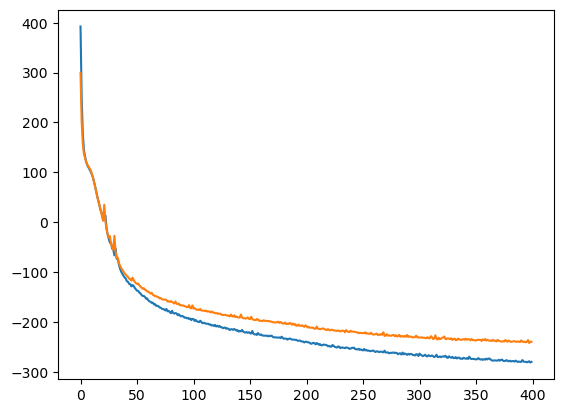

In [9]:
import matplotlib.pyplot as plt

torch.save(nfm.state_dict(), f=f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/spline_flow_K={K}_LS={latent_size}_HL{hidden_layers}_epochs={num_epochs}_no_context.pth')
plt.plot(train_losses)
plt.plot(val_losses)
nfm.eval()

num_samples = 1000

with torch.no_grad():
    x, _ = nfm.sample(num_samples=100)

x = x.detach().cpu().numpy().reshape(-1, 200, 2)
print(x.shape)

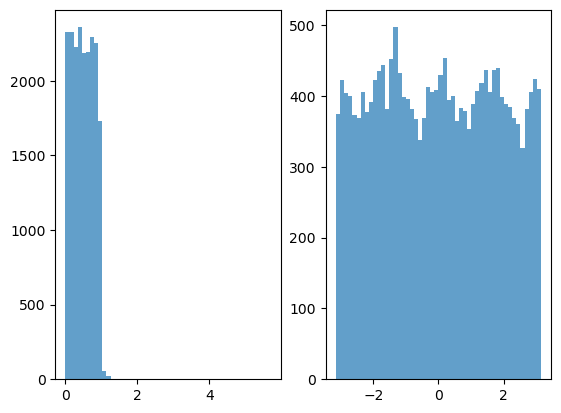

In [10]:
radii = np.linalg.norm(x, axis=-1)
thetas = np.atan2(x[..., 1], x[..., 0])

bins=50
alpha=.7
fig, ax = plt.subplots(ncols=2)
ax[0].hist((radii**2).ravel(), bins=bins, alpha=alpha)
ax[1].hist((thetas).ravel(), bins=bins, alpha=alpha)
plt.show()

In [3]:
import matplotlib.patches as ps

x_min = x[..., 0].min() - 0.02 * x[..., 0].min()
x_max = x[..., 0].max() + 0.02 * x[..., 0].max()

y_min = x[..., 1].min() - 0.02 * x[..., 1].min()
y_max = x[..., 1].max() + 0.02 * x[..., 1].min()

fig, ax = plt.subplots()
ax.set_box_aspect(1)
ax.add_patch(ps.Circle(xy=(0,0), radius=1.0, fill=None))
ax.scatter(*x[:50].T, s=1.5, alpha=.4)

ax.set_xlim(left=x_min, right=x_max)
ax.set_ylim(bottom=y_min, top=y_max)

NameError: name 'x' is not defined

In [2]:
def plot_2d_heatmap(points, title="Heatmap", R=1.0, bins=100):

    import matplotlib.patches as ps
        
    if isinstance(points, torch.Tensor):
        points = points.cpu().numpy()

    x = points[:, 0]
    y = points[:, 1]
    
    range_ = [[-R-pad, R+pad], [-R-pad, R+pad]]

    fig, ax = plt.subplots()
    H , xedges, yedges, im = ax.hist2d(x, y, bins=bins, range=range_, cmap='RdBu_r')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('counts')
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    ax.add_patch(ps.Circle(xy=(0,0), radius=R, fill=None, color='w', zorder=6))

nfm.eval()
with torch.no_grad():

SyntaxError: incomplete input (821296754.py, line 24)